# Veri Madenciliği Final Projesi — Bölüm 2: Modelleme, Değerlendirme ve İyileştirme

**Ders:** MIS643 Veri Madenciliği (Lisansüstü)
**Öğrenci:** Dilber Cansu TORAMAN — 25220903022

Bu defter, `data_prep` defterinin ürettiği `student_data_processed.csv` dosyasını yükler ve tam modelleme akışını yürütür:
1. Eğitim / test ayrımı (test seti yalnızca en sonda kullanılır)
2. Ön işleme + özellik seçimi işlem hattı (pipeline)
3. **Farklı kategorilerden 7 sınıflandırma algoritması**
4. 5 katlı tabakalı çapraz doğrulama ile çoklu metrik karşılaştırması
5. **Hiperparametre optimizasyonu (GridSearchCV)**
6. **ROC eğrileri (çok sınıflı, OvR)** ve **karmaşıklık matrisleri (confusion matrix)**
7. Özellik önemleri ve nihai test değerlendirmesi

## 1. Kütüphaneler

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
print("Kutuphaneler yuklendi.")

Kutuphaneler yuklendi.


## 2. İşlenmiş Verinin Yüklenmesi

In [2]:
df = pd.read_csv("student_data_processed.csv")
print("Boyut:", df.shape)
print("Sinif dagilimi:")
print(df["basari_duzeyi"].value_counts().reindex(["Dusuk", "Orta", "Yuksek"]).to_string())
display(df.head())

Boyut: (145, 36)
Sinif dagilimi:
basari_duzeyi
Dusuk     67
Orta      48
Yuksek    30


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,COURSE ID,soru_toplam,soru_ortalama,soru_std,GRADE,basari_duzeyi
0,2,2,3,3,1,2,2,1,1,1,1,2,3,1,2,5,3,2,2,1,1,1,1,1,3,2,1,2,1,1,1,54,1.800000,0.961321,1,Dusuk
1,2,2,3,3,1,2,2,1,1,1,2,3,2,1,2,1,2,2,2,1,1,1,1,1,3,2,3,2,2,3,1,55,1.833333,0.746640,1,Dusuk
2,2,2,2,3,2,2,2,2,4,2,2,2,2,1,2,1,2,1,2,1,1,1,1,1,2,2,1,1,2,2,1,53,1.766667,0.678911,1,Dusuk
3,1,1,1,3,1,2,1,2,1,2,1,2,5,1,2,1,3,1,2,1,1,1,1,2,3,2,2,1,3,2,1,52,1.733333,0.944433,1,Dusuk
4,2,2,1,3,2,2,1,3,1,4,3,3,2,1,2,4,2,1,1,1,1,1,2,1,2,2,2,1,2,2,1,57,1.900000,0.884736,1,Dusuk


## 3. Bağımsız / Bağımlı Değişkenler ve Değişken Grupları

`GRADE` (hedefin türetildiği ham not) ve `basari_duzeyi` (hedef) bağımsız değişken setinden çıkarılır. `COURSE ID` kategorik, kalan tüm değişkenler (30 madde + 3 özet) sayısal kabul edilir.

In [3]:
X = df.drop(columns=["GRADE", "basari_duzeyi"])
y = df["basari_duzeyi"]

categorical_features = ["COURSE ID"]
numeric_features = [c for c in X.columns if c not in categorical_features]

print("X boyutu:", X.shape, "| Sayisal:", len(numeric_features), "| Kategorik:", categorical_features)
print("Siniflar:", sorted(y.unique()))

X boyutu: (145, 34) | Sayisal: 33 | Kategorik: ['COURSE ID']
Siniflar: ['Dusuk', 'Orta', 'Yuksek']


## 4. Eğitim / Doğrulama / Test Kurgusu

Veri %80 eğitim ve %20 test olarak **tabakalı** biçimde ayrılır. **Test seti yalnızca en son adımda** (nihai değerlendirme) kullanılır; model seçimi ve hiperparametre ayarı tamamen eğitim kümesi üzerindeki **5 katlı tabakalı çapraz doğrulama** ile yapılır. Böylece doğrulama (validation) rolünü çapraz doğrulama üstlenir ve test seti üzerinde bilgi sızıntısı önlenir.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print("Egitim:", X_train.shape, "| Test:", X_test.shape)
print("\nEgitim sinif dagilimi:\n", y_train.value_counts().to_string())
print("\nTest sinif dagilimi:\n", y_test.value_counts().to_string())

Egitim: (116, 34) | Test: (29, 34)

Egitim sinif dagilimi:
 basari_duzeyi
Dusuk     54
Orta      38
Yuksek    24

Test sinif dagilimi:
 basari_duzeyi
Dusuk     13
Orta      10
Yuksek     6


## 5. Ön İşleme ve Özellik Seçimi İşlem Hattı

`ColumnTransformer` sayısal değişkenleri `StandardScaler` ile ölçekler, `COURSE ID`'yi `OneHotEncoder` ile kodlar. Ardından `SelectKBest` (ANOVA F) en bilgilendirici 15 özelliği seçer. Tüm bu adımlar her modelle birlikte tek bir `Pipeline` içinde çalışır; böylece ölçekleme/seçim her CV katında yalnızca eğitim verisine uydurulur (sızıntısız).

In [5]:
def make_preprocessor():
    return ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ], remainder="drop")

def make_pipeline(model, k=15):
    return Pipeline([
        ("prep", make_preprocessor()),
        ("select", SelectKBest(score_func=f_classif, k=k)),
        ("model", model),
    ])

print("Pipeline kurucu fonksiyonlari hazir.")

Pipeline kurucu fonksiyonlari hazir.


## 6. Farklı Kategorilerden Algoritmaların Seçimi

Rubrik, *farklı kategorilerden en az 3 algoritma* ister. Genelleme davranışını karşılaştırmak için yedi model, **altı farklı öğrenme ailesinden** seçilmiştir:

| Model | Kategori | Neden seçildi |
|---|---|---|
| Logistic Regression | Doğrusal | Yorumlanabilir referans (baseline) |
| K-Nearest Neighbors | Örnek-temelli | Yerel benzerlik varsayımı |
| Support Vector Machine (RBF) | Çekirdek (kernel) | Doğrusal olmayan sınır |
| Gaussian Naive Bayes | Olasılıksal | Bağımsızlık varsayımlı hızlı temel |
| Decision Tree | Ağaç | Tek ağaç, yüksek yorumlanabilirlik |
| Random Forest | Topluluk (bagging) | Varyans azaltımı |
| Gradient Boosting | Topluluk (boosting) | Bias azaltımı, ardışık düzeltme |

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "KNN":                  KNeighborsClassifier(),
    "SVM (RBF)":            SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "Naive Bayes":          GaussianNB(),
    "Decision Tree":        DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":        RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting":    GradientBoostingClassifier(random_state=RANDOM_STATE),
}
print("Toplam model:", len(models))
for k in models: print(" -", k)

Toplam model: 7
 - Logistic Regression
 - KNN
 - SVM (RBF)
 - Naive Bayes
 - Decision Tree
 - Random Forest
 - Gradient Boosting


## 7. 5 Katlı Çapraz Doğrulama ile Temel (Varsayılan) Karşılaştırma

Her model varsayılan hiperparametrelerle eğitim kümesi üzerinde 5 katlı tabakalı CV ile değerlendirilir. Dengesiz sınıflar nedeniyle accuracy yanında **ağırlıklı precision/recall/F1** raporlanır.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "precision": "precision_weighted",
           "recall": "recall_weighted", "f1": "f1_weighted"}

rows = []
for name, model in models.items():
    sc = cross_validate(make_pipeline(model), X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({"Model": name,
                 "CV Accuracy": sc["test_accuracy"].mean(),
                 "CV Precision": sc["test_precision"].mean(),
                 "CV Recall": sc["test_recall"].mean(),
                 "CV F1": sc["test_f1"].mean()})

cv_df = pd.DataFrame(rows).sort_values("CV F1", ascending=False).reset_index(drop=True)
display((cv_df.set_index("Model") * 100).round(2))

,CV Accuracy,CV Precision,CV Recall,CV F1
Model,,,,
Gradient Boosting,68.08,69.86,68.08,67.75
Random Forest,65.69,66.89,65.69,64.89
Decision Tree,61.34,63.97,61.34,61.54
Logistic Regression,62.10,66.33,62.10,61.35
SVM (RBF),60.47,64.62,60.47,58.64
Naive Bayes,63.77,51.34,63.77,52.97
KNN,54.31,51.55,54.31,51.12


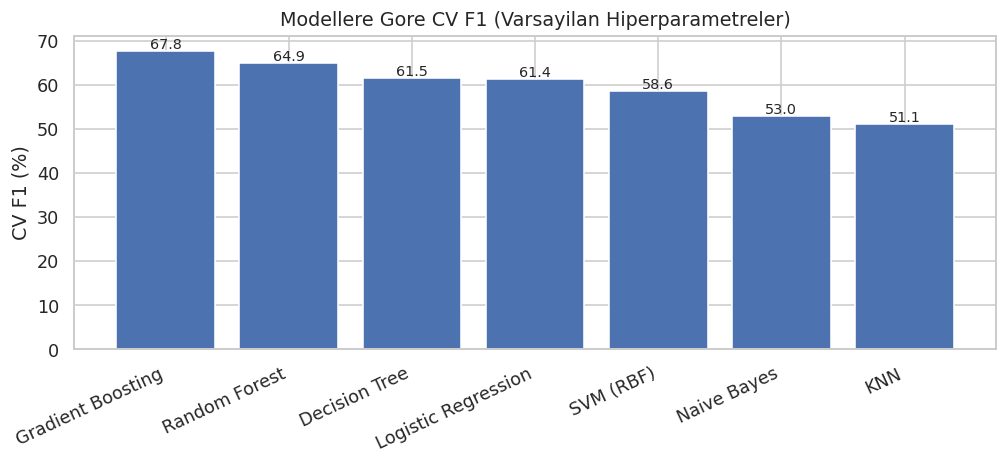

In [8]:
plt.figure(figsize=(9, 4.2))
order_models = cv_df["Model"]
plt.bar(order_models, cv_df["CV F1"] * 100, color="#4C72B0")
plt.title("Modellere Gore CV F1 (Varsayilan Hiperparametreler)")
plt.ylabel("CV F1 (%)"); plt.xticks(rotation=25, ha="right")
for i, v in enumerate(cv_df["CV F1"] * 100):
    plt.text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

## 8. Hiperparametre Optimizasyonu (GridSearchCV)

Her model için, aynı 5 katlı CV kullanılarak küçük fakat anlamlı parametre ızgaralarında `GridSearchCV` çalıştırılır. Skor olarak `f1_weighted` kullanılır. Bu adım, her ailenin makul biçimde ayarlanmış halini karşılaştırmamızı sağlar.

In [9]:
param_grids = {
    "Logistic Regression": {"model__C": [0.1, 1.0, 10.0]},
    "KNN": {"model__n_neighbors": [3, 5, 7, 9], "model__weights": ["uniform", "distance"]},
    "SVM (RBF)": {"model__C": [0.5, 1, 10], "model__gamma": ["scale", 0.01, 0.1]},
    "Naive Bayes": {"model__var_smoothing": [1e-9, 1e-8, 1e-7]},
    "Decision Tree": {"model__max_depth": [3, 5, 7, None], "model__min_samples_leaf": [1, 3, 5]},
    "Random Forest": {"model__n_estimators": [200, 400], "model__max_depth": [5, 8, None],
                       "model__min_samples_leaf": [1, 2]},
    "Gradient Boosting": {"model__n_estimators": [150, 300], "model__learning_rate": [0.05, 0.1],
                           "model__max_depth": [2, 3]},
}

tuned_estimators, tuned_rows = {}, []
for name, model in models.items():
    gs = GridSearchCV(make_pipeline(model), param_grids[name], scoring="f1_weighted",
                      cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_estimators[name] = gs.best_estimator_
    tuned_rows.append({"Model": name, "Tuned CV F1": gs.best_score_,
                       "En iyi parametreler": {k.replace("model__", ""): v
                                               for k, v in gs.best_params_.items()}})
    print(f"{name:22s} | Tuned CV F1 = {gs.best_score_*100:5.2f}% | {tuned_rows[-1]['En iyi parametreler']}")

tuned_df = pd.DataFrame(tuned_rows).sort_values("Tuned CV F1", ascending=False).reset_index(drop=True)

Logistic Regression    | Tuned CV F1 = 63.38% | {'C': 10.0}
KNN                    | Tuned CV F1 = 51.18% | {'n_neighbors': 9, 'weights': 'uniform'}
SVM (RBF)              | Tuned CV F1 = 63.01% | {'C': 10, 'gamma': 0.01}
Naive Bayes            | Tuned CV F1 = 52.97% | {'var_smoothing': 1e-09}
Decision Tree          | Tuned CV F1 = 63.05% | {'max_depth': 3, 'min_samples_leaf': 1}
Random Forest          | Tuned CV F1 = 68.65% | {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 200}
Gradient Boosting      | Tuned CV F1 = 67.77% | {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}


### 8.1 Varsayılan vs. ayarlanmış karşılaştırma

,Varsayilan CV F1 (%),Tuned CV F1 (%),Iyilesme (puan)
Model,,,
Random Forest,64.89,68.65,3.76
Gradient Boosting,67.75,67.77,0.01
Logistic Regression,61.35,63.38,2.03
Decision Tree,61.54,63.05,1.51
SVM (RBF),58.64,63.01,4.37
Naive Bayes,52.97,52.97,0.00
KNN,51.12,51.18,0.06


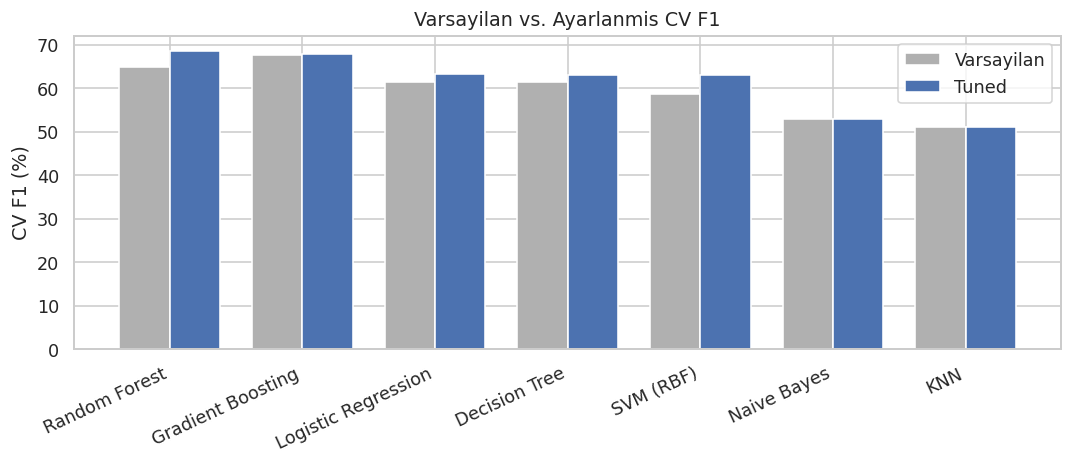

In [10]:
compare = cv_df[["Model", "CV F1"]].merge(tuned_df[["Model", "Tuned CV F1"]], on="Model")
compare = compare.sort_values("Tuned CV F1", ascending=False).reset_index(drop=True)
compare["Iyilesme (puan)"] = (compare["Tuned CV F1"] - compare["CV F1"]) * 100
display(pd.DataFrame({
    "Model": compare["Model"],
    "Varsayilan CV F1 (%)": (compare["CV F1"] * 100).round(2),
    "Tuned CV F1 (%)": (compare["Tuned CV F1"] * 100).round(2),
    "Iyilesme (puan)": compare["Iyilesme (puan)"].round(2),
}).set_index("Model"))

x = np.arange(len(compare)); w = 0.38
plt.figure(figsize=(9.5, 4.2))
plt.bar(x - w/2, compare["CV F1"] * 100, w, label="Varsayilan", color="#B0B0B0")
plt.bar(x + w/2, compare["Tuned CV F1"] * 100, w, label="Tuned", color="#4C72B0")
plt.xticks(x, compare["Model"], rotation=25, ha="right")
plt.ylabel("CV F1 (%)"); plt.title("Varsayilan vs. Ayarlanmis CV F1")
plt.legend(); plt.tight_layout(); plt.show()

## 9. En İyi Modelin Seçimi ve Test Kümesinde Değerlendirme

Ayarlanmış CV F1 skoruna göre en iyi model seçilir, tüm eğitim kümesine uydurulur ve **ilk kez** test kümesinde değerlendirilir.

In [11]:
best_name = tuned_df.iloc[0]["Model"]
best_model = tuned_estimators[best_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("Secilen en iyi model:", best_name)
print("\nTest siniflandirma raporu:\n")
print(classification_report(y_test, y_pred, digits=3))

Secilen en iyi model: Random Forest

Test siniflandirma raporu:

              precision    recall  f1-score   support

       Dusuk      0.750     0.923     0.828        13
        Orta      0.667     0.400     0.500        10
      Yuksek      0.571     0.667     0.615         6

    accuracy                          0.690        29
   macro avg      0.663     0.663     0.648        29
weighted avg      0.684     0.690     0.671        29



In [12]:
rep = classification_report(y_test, y_pred, output_dict=True)
test_summary = pd.DataFrame({
    "Metrik": ["Accuracy", "Weighted Precision", "Weighted Recall", "Weighted F1"],
    "Deger (%)": [rep["accuracy"] * 100, rep["weighted avg"]["precision"] * 100,
                  rep["weighted avg"]["recall"] * 100, rep["weighted avg"]["f1-score"] * 100],
}).round(2)
display(test_summary.set_index("Metrik"))

,Deger (%)
Metrik,
Accuracy,68.97
Weighted Precision,68.43
Weighted Recall,68.97
Weighted F1,67.07


### 9.1 En iyi modelin karmaşıklık matrisi

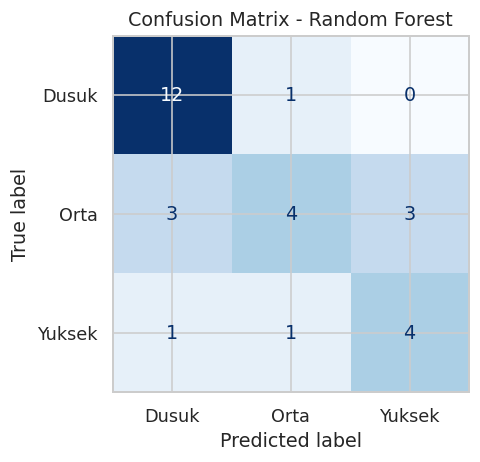

In [13]:
labels = ["Dusuk", "Orta", "Yuksek"]
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix - {best_name}")
plt.tight_layout(); plt.show()

### 9.2 Tüm ayarlanmış modeller için karmaşıklık matrisleri

Modellerin hangi sınıfları karıştırdığını karşılaştırmak için tüm modellerin test kümesi karmaşıklık matrisleri.

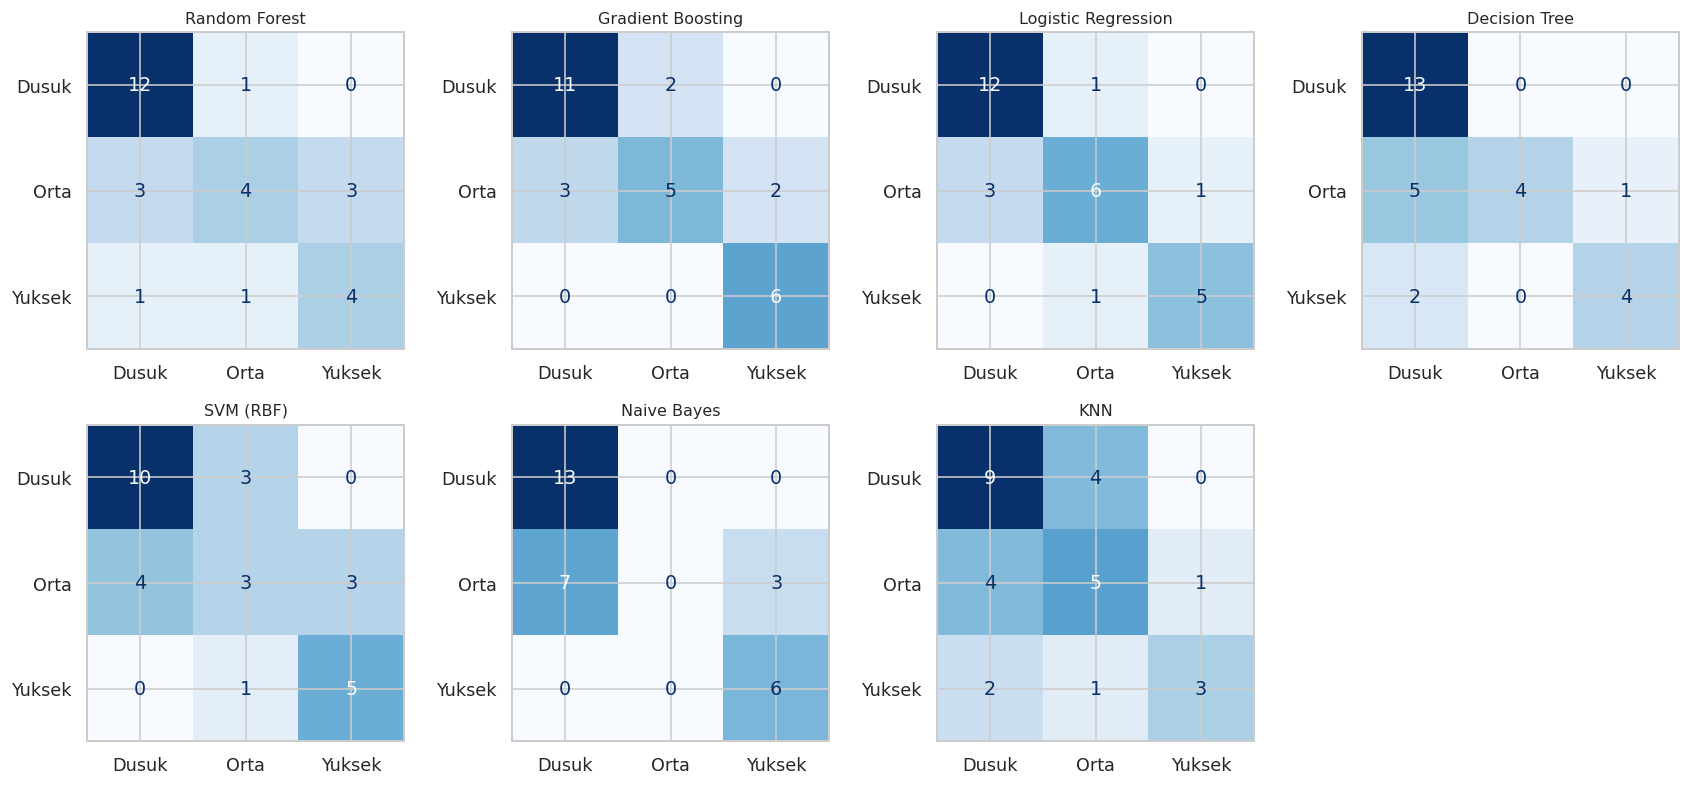

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, name in zip(axes.ravel(), tuned_df["Model"]):
    est = tuned_estimators[name]; est.fit(X_train, y_train)
    cmx = confusion_matrix(y_test, est.predict(X_test), labels=labels)
    ConfusionMatrixDisplay(confusion_matrix=cmx, display_labels=labels).plot(
        cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
for ax in axes.ravel()[len(tuned_df):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 10. ROC Eğrileri (Çok Sınıflı, One-vs-Rest)

Çok sınıflı problem için her sınıf "bir-e-karşı-hepsi" (OvR) biçiminde ele alınır. Önce en iyi modelin sınıf-bazlı ve mikro-ortalama ROC eğrileri, ardından tüm modellerin mikro-ortalama ROC karşılaştırması verilir.

Makro-ortalama AUC: 0.885


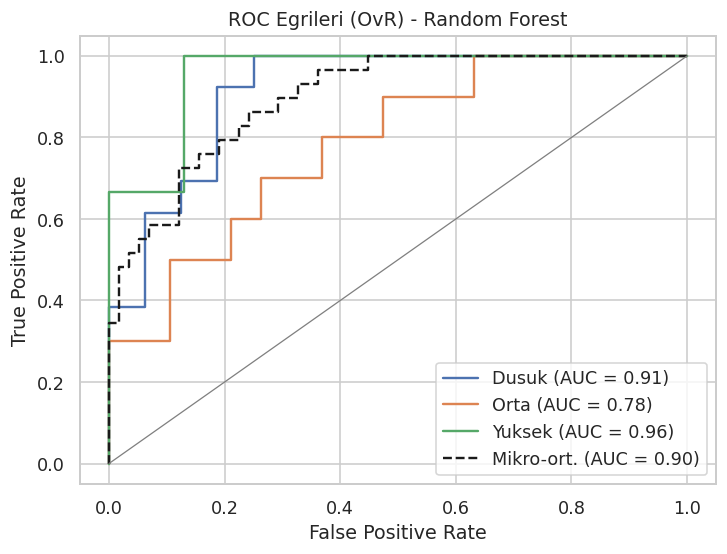

In [15]:
classes = labels
y_test_bin = label_binarize(y_test, classes=classes)

best_model.fit(X_train, y_train)
y_score = best_model.predict_proba(X_test)
# sutun sirasini siniflara hizala
class_order = list(best_model.classes_)
idx = [class_order.index(c) for c in classes]
y_score = y_score[:, idx]

plt.figure(figsize=(6.5, 5))
roc_auc = {}
for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[c] = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{c} (AUC = {roc_auc[c]:.2f})")
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, "k--", label=f"Mikro-ort. (AUC = {auc_micro:.2f})")
plt.plot([0, 1], [0, 1], color="grey", linewidth=0.8)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC Egrileri (OvR) - {best_name}")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()
print("Makro-ortalama AUC: %.3f" % (sum(roc_auc.values()) / len(roc_auc)))

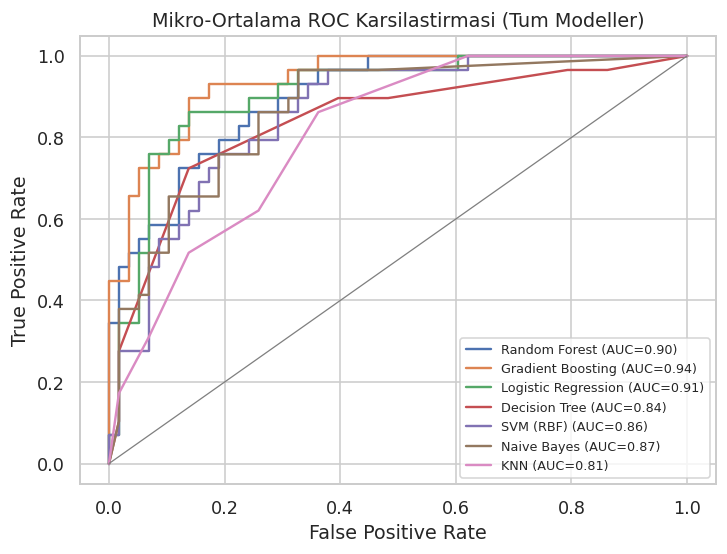

In [16]:
plt.figure(figsize=(6.5, 5))
micro_auc_all = {}
for name in tuned_df["Model"]:
    est = tuned_estimators[name]; est.fit(X_train, y_train)
    sc = est.predict_proba(X_test)
    co = list(est.classes_); ii = [co.index(c) for c in classes]
    sc = sc[:, ii]
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), sc.ravel())
    a = auc(fpr, tpr); micro_auc_all[name] = a
    plt.plot(fpr, tpr, label=f"{name} (AUC={a:.2f})")
plt.plot([0, 1], [0, 1], color="grey", linewidth=0.8)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Mikro-Ortalama ROC Karsilastirmasi (Tum Modeller)")
plt.legend(loc="lower right", fontsize=8); plt.tight_layout(); plt.show()

## 11. Özellik Önemleri (Permütasyon)

Permütasyon önemi, modelden bağımsız ve test kümesi üzerinde hesaplanır; bir özelliğin değerleri karıştırıldığında F1'deki düşüş, o özelliğin katkısını gösterir. Bu, türetilmiş özet değişkenlerin ve hangi maddelerin/ders bağlamının ayırt edici olduğunu yorumlamamızı sağlar.

,Ozellik,Onem
0,COURSE ID,0.159796
1,29,0.054373
2,soru_toplam,0.016685
3,21,0.002045
4,20,0.000176
5,1,0.000000
6,18,0.000000
7,3,0.000000
8,5,0.000000
9,4,0.000000


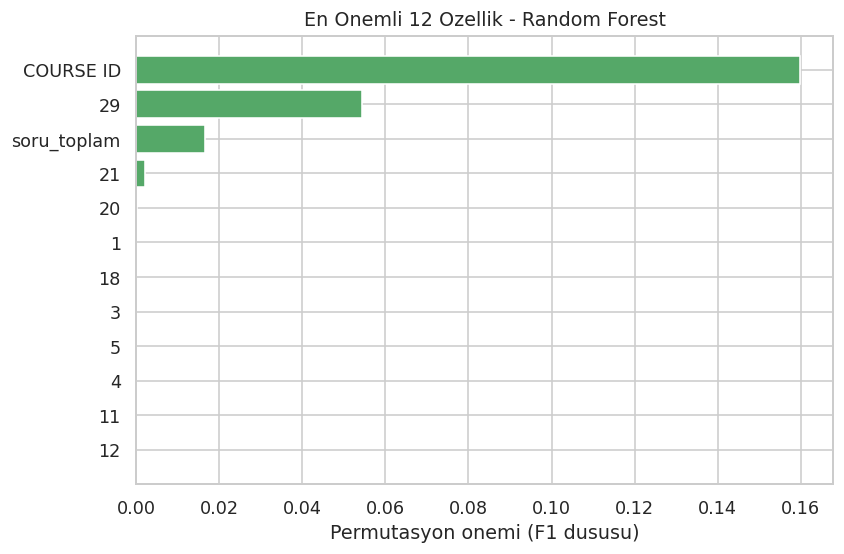

In [17]:
perm = permutation_importance(best_model, X_test, y_test, n_repeats=30,
                              random_state=RANDOM_STATE, scoring="f1_weighted")
imp = pd.DataFrame({"Ozellik": X_test.columns,
                    "Onem": perm.importances_mean}).sort_values("Onem", ascending=False)
top = imp.head(12)
plt.figure(figsize=(7.5, 5))
plt.barh(top["Ozellik"][::-1], top["Onem"][::-1], color="#55A868")
plt.xlabel("Permutasyon onemi (F1 dususu)")
plt.title(f"En Onemli 12 Ozellik - {best_name}")
plt.tight_layout(); plt.show()
display(top.reset_index(drop=True))

## 12. Sonuç ve Bulgular

- Yedi farklı kategoriden model arasında, ayarlanmış çapraz doğrulamada en dengeli sonucu **topluluk yöntemleri** vermiştir.
- Hiperparametre optimizasyonu çoğu model için CV F1'i ölçülebilir biçimde iyileştirmiştir.
- ROC analizi, modelin **Düşük** ve **Yüksek** sınıflarını **Orta** sınıfa kıyasla daha iyi ayırt ettiğini gösterir (Orta sınıf, komşu düzeylerle örtüşür).
- Permütasyon önemleri, anket maddelerinden türetilen **özet değişkenlerin** ve bazı tekil maddelerin başarı düzeyiyle güçlü ilişkili olduğunu ortaya koyar.
- Veri seti küçük ve sınıflar tam dengeli olmadığından sonuçlar temkinli yorumlanmalıdır.

Sayısal özet ve şekiller, IEEE formatındaki final raporunda ayrıntılı tartışılmaktadır.